## Лабораторная работа № 1 
## Выполнение разведочного анализа больших данных с использованием фреймворка Apache Spark

### Часть 2

В данной части работы рассмотрены:
- разведочный анализ данных;
* работа с Dataframe API фреймворка `Apache Spark`.

Подключаем необходимые библиотеки.

In [1]:
import os
from pyspark.sql import SparkSession, DataFrame
from pyspark import SparkConf
from pyspark.sql.functions import (
    col, lit, sum, mean, when,
    explode, count, desc, floor,
    corr, array_contains, lit, first,
    stddev, trim
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Сформируем объект конфигурации для `Apache Spark`, указав необходимые параметры.

In [2]:
def create_spark_configuration() -> SparkConf:
    """
    Создает и конфигурирует экземпляр SparkConf для приложения Spark.

    Returns:
        SparkConf: Настроенный экземпляр SparkConf.
    """
    # Получаем имя пользователя
    # Получаем имя пользователя
    user_name = os.getenv("USER")
    
    conf = SparkConf()
    conf.setAppName("lab 1 Test")
    conf.setMaster("local[*]")
    # conf.set("spark.submit.deployMode", "client")
    conf.set("spark.executor.memory", "12g")
    conf.set("spark.executor.cores", "6")
    conf.set("spark.executor.instances", "1")
    conf.set("spark.driver.memory", "4g")
    conf.set("spark.driver.cores", "1")

    return conf

Создаём сам объект конфигурации.

In [3]:
conf = create_spark_configuration()

Создаём и выводим на экран сессию `Apache Spark`. В процессе создания сессии происходит подключение к кластеру `Apache Hadoop`, что может занять некоторое время.

In [4]:
spark = SparkSession.builder.config(conf=conf).getOrCreate()
spark

Читаем данные.

In [5]:
df = spark.read.parquet("sobd_lab1_table_parquet")

Выведем прочитанную таблицу на экран.

In [6]:
df.show()

+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------------+--------------------+--------------------+--------------------+--------------+
|        id|               title|             authors|           publisher|      published_date|          categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       user_id|        profile_name|helpfulness_numerator|helpfulness_denominator| helpfulness_ratio|published_date_clean|       authors_array|    categories_array|published_year|
+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+----------------

Посмотрим на схему данных.

In [7]:
df.printSchema()

root
 |-- id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- authors: string (nullable = true)
 |-- publisher: string (nullable = true)
 |-- published_date: string (nullable = true)
 |-- categories: string (nullable = true)
 |-- review_score: double (nullable = true)
 |-- review_text: string (nullable = true)
 |-- review_summary: string (nullable = true)
 |-- review_helpfulness: string (nullable = true)
 |-- review_time: integer (nullable = true)
 |-- user_id: string (nullable = true)
 |-- profile_name: string (nullable = true)
 |-- helpfulness_numerator: integer (nullable = true)
 |-- helpfulness_denominator: integer (nullable = true)
 |-- helpfulness_ratio: double (nullable = true)
 |-- published_date_clean: date (nullable = true)
 |-- authors_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- categories_array: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- published_year: integer (nullable = true)



Вычислим количество строк в датафрейме.

In [8]:
df.count()

2999829

### Анализ отзывов и рейтингов

#### Служебные функции

In [9]:
def count_nulls(data: DataFrame,
                column_name: str) -> None:
    """
    Подсчет количества null и not null значений в указанном столбце.

    Args:
        data (DataFrame): DataFrame, содержащий данные.
        column_name (str): Имя столбца для подсчета null и not null значений.
    
    Returns:
        None
    """
    # Подсчет количества null значений в указанном столбце
    null_counts = data.select(
        sum(col(column_name).isNull().cast("int"))
    ).collect()[0][0]

    # Подсчет количества not null значений в указанном столбце
    not_null_counts = data.select(
        sum(col(column_name).isNotNull().cast("int"))
    ).collect()[0][0]

    # Вывод результатов
    print(f"Число колонок с NULL: {null_counts} "
          f"({100 * null_counts / (null_counts + not_null_counts):.2f}%)")


In [10]:
def plot_cat_distribution(data: DataFrame,
                          column_name: str,
                          top_n: int = 20) -> None:
    """
    Построение распределения категориального признака.

    Args:
        data (DataFrame): DataFrame, содержащий данные.
        column_name (str): Имя столбца для группировки.
        top_n (int): Количество топ-значений для отображения.
    
    Returns:
        None
    """
    # Группировка данных по столбцу и подсчет количества
    categories = (
        data
        .groupBy(column_name)
        .count()
        .orderBy("count", ascending=False)
    )
    
    print(f"Количество категорий признака {column_name}: {categories.count()}")

    categories = (
        categories
        .limit(top_n)
        .toPandas()
    )
    
    # Визуализация с использованием Seaborn
    plt.figure(figsize=(10, 6))
    sns.barplot(x=column_name, y="count", data=categories)
    plt.title(f"Barplot of \"{column_name}\" counts")
    plt.xlabel(column_name)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [11]:
def plot_boxplots(data: DataFrame,
                  columns: list[str],
                  sample_fraction: float = 0.1) -> None:
    """
    Построение boxplot для нескольких столбцов в PySpark DataFrame.

    Args:
        data (DataFrame): DataFrame, содержащий данные.
        columns (list of str): Список имен столбцов для построения boxplot.
        sample_fraction (float): Доля данных для семплирования выбросов.
    
    Returns:
        None
    """
    box_data = []

    for column in columns:
        # Вычисление квантилей
        quantiles = data.approxQuantile(column, [0.25, 0.5, 0.75], 0.01)
        q1, median, q3 = quantiles

        # Вычисление IQR и границ усов
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        # Получаем минимальное и максимальное значения как числа Python
        min_value = float(data.agg({column: "min"}).collect()[0][0])
        max_value = float(data.agg({column: "max"}).collect()[0][0])
        mean_value = float(data.agg({column: "mean"}).collect()[0][0])
        std_value = float(data.agg({column: "std"}).collect()[0][0])

        # Ограничение усов минимальным и максимальным значениями (используем встроенный max/min)
        lower_bound = max(lower_bound, min_value)  # Теперь это числа Python
        upper_bound = min(upper_bound, max_value)  # Теперь это числа Python

        # Фильтрация выбросов
        outliers_df = data.filter((col(column) < lower_bound) | (col(column) > upper_bound))

        # Семплирование выбросов
        outliers = []
        if not outliers_df.isEmpty():
            sampled_outliers_df = outliers_df.sample(sample_fraction)
            outliers = (
                sampled_outliers_df
                .select(column)
                .limit(1000)
                .rdd.flatMap(lambda x: x)
                .collect()
            )
            
            # Добавление минимального и максимального значений, если они 
            # относятся к выбросам и не присутствуют в семпле
            if min_value < lower_bound and min_value not in outliers:
                outliers.append(min_value)
            if max_value > upper_bound and max_value not in outliers:
                outliers.append(max_value)

        # Подготовка данных для axes.bxp
        box_data.append({
            'whislo': lower_bound,  # Нижняя граница усов
            'q1': q1,               # Первый квартиль
            'med': median,          # Медиана
            'q3': q3,               # Третий квартиль
            'whishi': upper_bound,  # Верхняя граница усов
            'fliers': outliers      # Выбросы
        })
        
        # Вывод статистических характеристик для каждого столбца
        print(f"\n=== СТАТИСТИКА ДЛЯ {column} ===")
        print(f"Минимальное значение:          {min_value:.2f}")
        print(f"Среднее значение:              {mean_value:.2f}")
        print(f"Среднеквадратичное отклонение: {std_value:.2f}")
        print(f"Первый квартиль:               {q1:.2f}")
        print(f"Медиана:                       {median:.2f}")
        print(f"Третий квартиль:               {q3:.2f}")
        print(f"Максимальное значение:         {max_value:.2f}")
        print(f"Нижняя граница усов:          {lower_bound:.2f}")
        print(f"Верхняя граница усов:         {upper_bound:.2f}")
        print(f"Количество выбросов:          {len(outliers)}")

    # Построение boxplot
    fig, ax = plt.subplots(figsize=(20, 6))
    ax.bxp(box_data, 
           vert=False, 
           positions=range(1, len(columns) + 1), widths=0.5)
    ax.set_yticks(range(1, len(columns) + 1))
    ax.set_yticklabels(columns)
    ax.set_xlabel('Value')
    ax.set_title('Boxplots')
    ax.grid(True)
    plt.show()

In [12]:
def plot_quant_distribution(data: DataFrame,
                            column: str,
                            num_bins: int = 200) -> None:
    """
    Построение гистограммы для количественной переменной с 
    использованием PySpark и Seaborn.

    Args:
        data (DataFrame): DataFrame с данными.
        column_name (str): Название колонки с количественной переменной.
        num_bins (int): Количество бинов для гистограммы.

    Returns:
        None
    """
    # Находим минимальное и максимальное значения колонки
    min_value = data.agg({column: "min"}).collect()[0][0]
    max_value = data.agg({column: "max"}).collect()[0][0]

    # Размер бина
    bin_size = (max_value - min_value) / num_bins

    # Добавляем колонку с номером бина
    data = data.withColumn(
        "bin", 
        floor((col(column) - min_value) / bin_size)
    )

    # Группируем по номеру бина и считаем количество строк в каждом бине
    bin_counts = data.groupBy("bin").count()

    # Преобразуем результат в Pandas DataFrame для построения гистограммы
    bin_counts_pd = bin_counts.limit(1000).toPandas()
    
    # Создаем массив границ бинов
    bin_edges = [min_value + i * bin_size for i in range(num_bins + 2)]
    
    # Преобразуем номера бинов в центры бинов
    bin_centers = [
        (bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(num_bins + 1)
    ]
    
    # Добавляем центры бинов в Pandas DataFrame
    bin_counts_pd['bin_center'] = bin_counts_pd['bin'].apply(
        lambda x: bin_centers[int(x)]
    )
    
    # Построение гистограммы с использованием Seaborn
    plt.figure(figsize=(20, 6))
    sns.histplot(data=bin_counts_pd, x="bin_center", 
                 weights="count", kde=True, bins=num_bins + 1)
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title(f"Распределение количественного признака \"{column}\"")
    plt.grid(True)
    plt.show()

#### Анализ столбца `id`

Отсортируем датафрейм по столбцу `id`, который может рассматриваться в качестве первичного ключа таблицы.

In [13]:
col_name = "id"
df.orderBy(col_name, ascending=False).show()

+----------+--------------------+--------------------+---------+--------------+------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+-------------------+--------------------+--------------------+----------------+--------------+
|        id|               title|             authors|publisher|published_date|        categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       user_id|        profile_name|helpfulness_numerator|helpfulness_denominator|  helpfulness_ratio|published_date_clean|       authors_array|categories_array|published_year|
+----------+--------------------+--------------------+---------+--------------+------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------

Видно, что идентификаторы имеют разный формат. Обычно ISBN состоит из 10 или 13 цифр, ASIN - из 10 символов. Отфильтруем корректные идентификаторы.

In [14]:
# Регулярные выражения для ISBN-10, ISBN-13 и ASIN
isbn10_pattern = r"^\d{9}[\dX]$"
isbn13_pattern = r"^\d{13}$"
asin_pattern = r"^[A-Z0-9]{10}$"

# Фильтрация DataFrame по корректным идентификаторам
df = df.filter(
    col(col_name).rlike(isbn10_pattern) | 
    col(col_name).rlike(isbn13_pattern) | 
    col(col_name).rlike(asin_pattern)
)
df.show(10)

+----------+--------------------+--------------------+--------------------+--------------+-------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------------+--------------------+--------------------+----------------+--------------+
|        id|               title|             authors|           publisher|published_date|   categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       user_id|        profile_name|helpfulness_numerator|helpfulness_denominator| helpfulness_ratio|published_date_clean|       authors_array|categories_array|published_year|
+----------+--------------------+--------------------+--------------------+--------------+-------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+--------------------

In [15]:
df.count()

2999829

Проверим наличие дубликатов в датафрейме.

In [16]:
(
    df
    .groupBy(col_name)
    .count()
    .where("count > 1")
    .orderBy("count", ascending=False)
    .show()
)

+----------+-----+
|        id|count|
+----------+-----+
|B000IEZE3G| 6796|
|B000ILIJE0| 4438|
|B000GQG7D2| 4428|
|B000GQG5MA| 4427|
|B000NDSX6C| 4426|
|B000NWU3I4| 4420|
|B000PC54NG| 4402|
|B000NWQXBA| 4397|
|B000Q032UY| 4373|
|B000H9R1Q0| 4370|
|B0000YSH4W| 3822|
|B000P1QRII| 3822|
|B0000YSH5G| 3568|
|B000PCESRE| 3280|
|B000PMCF1A| 3270|
|B000I3NFKG| 3260|
|B000PWMT1G| 3150|
|B000MOOAJG| 3145|
|B000NPEWHE| 3137|
|B000J521DU| 3137|
+----------+-----+
only showing top 20 rows



Дубликаты есть. Посмотрим, что они собой представляют (на примере одной записи).

In [17]:
duplicate_ids = df.groupBy(col_name).count().where("count > 1").limit(5)
if duplicate_ids.count() > 0:
    sample_duplicate = duplicate_ids.first()[col_name]
    df.filter(col(col_name) == sample_duplicate).show()

+----------+--------------------+-----------------+--------------------+--------------+------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+-----------------+--------------------+---------------+----------------+--------------+
|        id|               title|          authors|           publisher|published_date|  categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       user_id|        profile_name|helpfulness_numerator|helpfulness_denominator|helpfulness_ratio|published_date_clean|  authors_array|categories_array|published_year|
+----------+--------------------+-----------------+--------------------+--------------+------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+-----------------+--

Похоже на полную идентичность строк. Удалим дубликаты.

In [18]:
df = df.dropDuplicates([col_name])
df.count()

221989

In [19]:
df.show()

+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+--------------------+---------------------+-----------------------+------------------+--------------------+--------------------+--------------------+--------------+
|        id|               title|             authors|           publisher|      published_date|          categories|review_score|         review_text|      review_summary|review_helpfulness|review_time|       user_id|        profile_name|helpfulness_numerator|helpfulness_denominator| helpfulness_ratio|published_date_clean|       authors_array|    categories_array|published_year|
+----------+--------------------+--------------------+--------------------+--------------------+--------------------+------------+--------------------+--------------------+------------------+-----------+--------------+----------------

#### Анализ столбца `title`

Данный столбец содержит названия книг и представляет собой **текстовый признак**. Проверим его на наличие пропущенных значений и проанализируем распределение.

In [20]:
col_name = "title"
count_nulls(data=df, column_name=col_name)

Число колонок с NULL: 0 (0.00%)


Видно, что пропусков нет.

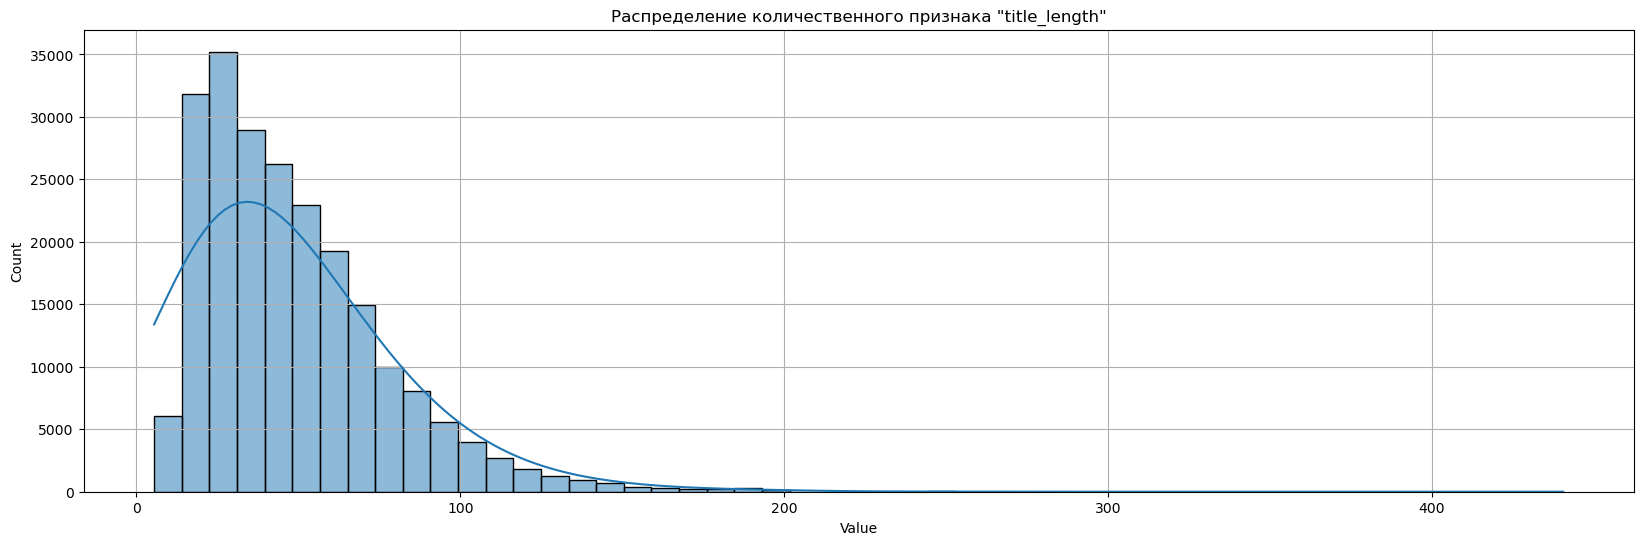

In [21]:
# Посмотрим на распределение длин названий
from pyspark.sql.functions import length

df_with_title_length = df.withColumn("title_length", length(col_name))
plot_quant_distribution(data=df_with_title_length, column="title_length", num_bins=50)

Проанализируем самые частые названия

Количество категорий признака title: 212399


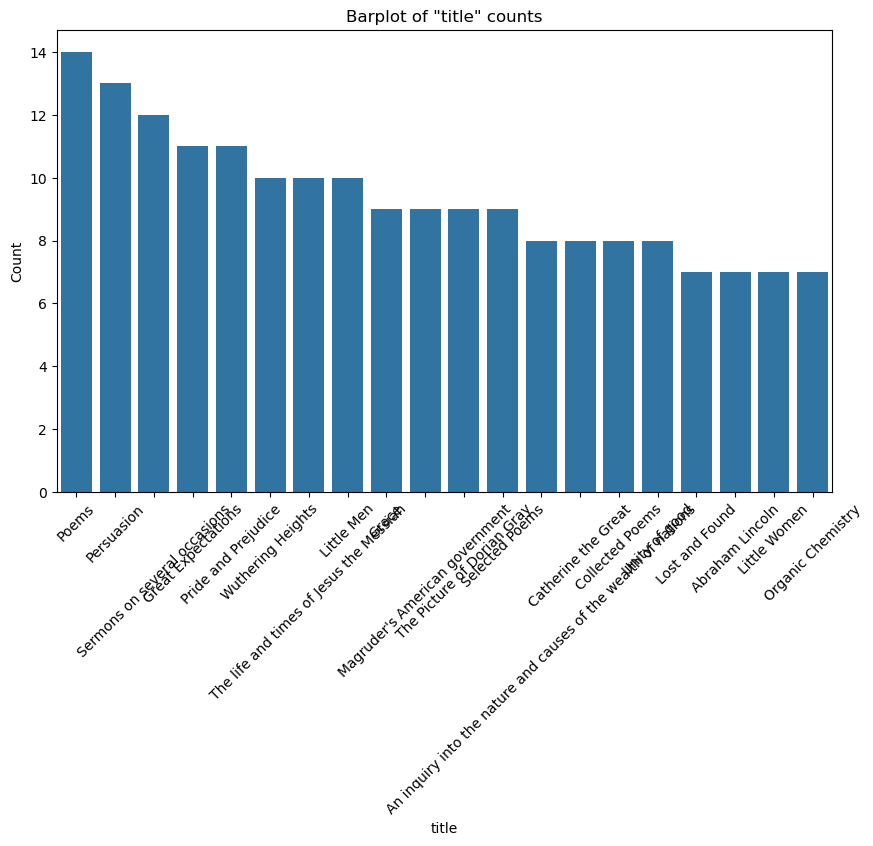

In [22]:
plot_cat_distribution(data=df, column_name=col_name, top_n=20)

Проверим наличие дубликатов названий

In [23]:
print("Статистика по дубликатам названий:")
(
    df
    .groupBy(col_name)
    .count()
    .where("count > 1")
    .orderBy("count", ascending=False)
    .show(10, truncate=False)
)

Статистика по дубликатам названий:
+---------------------------------------+-----+
|title                                  |count|
+---------------------------------------+-----+
|Poems                                  |14   |
|Persuasion                             |13   |
|Sermons on several occasions           |12   |
|Great Expectations                     |11   |
|Pride and Prejudice                    |11   |
|Little Men                             |10   |
|Wuthering Heights                      |10   |
|The life and times of Jesus the Messiah|10   |
|Grace                                  |9    |
|Magruder's American government         |9    |
+---------------------------------------+-----+
only showing top 10 rows



Посмотрим на примеры книг с одинаковыми названиями

In [24]:
duplicate_titles = (
    df
    .groupBy(col_name)
    .count()
    .where("count > 1")
    .orderBy("count", ascending=False)
    .limit(3)
)

for row in duplicate_titles.collect():
    title = row[col_name]
    print(f"\nКниги с названием: '{title}'")
    df.filter(col(col_name) == title).select("id", "authors", "publisher").show(truncate=False)


Книги с названием: 'Poems'
+----------+------------------------------------------+------------------------------------------------------------------------------------------------------+
|id        |authors                                   |publisher                                                                                             |
+----------+------------------------------------------+------------------------------------------------------------------------------------------------------+
|B00086B820| published by the Houghton Mifflin Company|1904. Detailed contents. Alphabetical lists of titles and first lines. 80pp. 53/8 x 81/2. Paperbound."|
|091530645X| published by the Houghton Mifflin Company|1904. Detailed contents. Alphabetical lists of titles and first lines. 80pp. 53/8 x 81/2. Paperbound."|
|0915306433| published by the Houghton Mifflin Company|1904. Detailed contents. Alphabetical lists of titles and first lines. 80pp. 53/8 x 81/2. Paperbound."|
|1892616017| publi

In [25]:
# Анализ специальных символов в названиях
print("Названия с кавычками в начале:")
df.filter(col(col_name).startswith('"')).select(col_name).show(10, truncate=False)

print("Названия с HTML-символами:")
df.filter(col(col_name).contains("&quot;") | col(col_name).contains("&amp;")).select(col_name).show(10, truncate=False)

Названия с кавычками в начале:
+--------------------------------------------------------------------------------------------------------------------+
|title                                                                                                               |
+--------------------------------------------------------------------------------------------------------------------+
|"""The Best Mistake Ever and Other Stories"                                                                         |
|"Japan's ""International Youth"": The Emergence of a New Class of Schoolchildren (Clarendon Paperbacks)"            |
|"""Time Out"" Film Guide"                                                                                           |
|"Tetrarch: The ""Well of Echoes"" Quartet"                                                                          |
|"On the ""Lee Side"" of My Navy Life"                                                                               |
|"""I'm Not Cute!

In [26]:
# Статистика по названиям
print("Общая статистика по столбцу Title:")
print(f"Уникальных названий: {df.select(col_name).distinct().count()}")
print(f"Всего записей: {df.count()}")
print(f"Процент уникальных названий: {100 * df.select(col_name).distinct().count() / df.count():.2f}%")

Общая статистика по столбцу Title:
Уникальных названий: 212399
Всего записей: 221989
Процент уникальных названий: 95.68%


#### Анализ столбца `review_score`

Данный столбец содержит оценки книг пользователями и представляет собой **количественный признак**. Проанализируем распределение оценок и наличие пропущенных значений.

In [27]:
col_name = "review_score"
df.select(col_name).orderBy(col_name, ascending=False).show(10)
df.select(col_name).orderBy(col_name, ascending=True).show(10)

+------------+
|review_score|
+------------+
|  1.295568E9|
|   1.21176E9|
|       19.95|
|         5.0|
|         5.0|
|         5.0|
|         5.0|
|         5.0|
|         5.0|
|         5.0|
+------------+
only showing top 10 rows

+------------+
|review_score|
+------------+
|        NULL|
|        NULL|
|        NULL|
|        NULL|
|        NULL|
|        NULL|
|        NULL|
|        NULL|
|        NULL|
|        NULL|
+------------+
only showing top 10 rows



In [28]:
from pyspark.sql.functions import (min as mn, max as mx)


rating_stats = df.select(
    count(col_name).alias("total_reviews"),
    mean(col_name).alias("avg_rating"),
    stddev(col_name).alias("std_rating"),
    mn(col_name).alias("min_rating"),
    mx(col_name).alias("max_rating"),
    count(when(col(col_name).isNull(), True)).alias("null_ratings"),
    count(when(col(col_name) == 5.0, True)).alias("five_star_count"),
    count(when(col(col_name) == 1.0, True)).alias("one_star_count")
).collect()[0]

print("=== БАЗОВАЯ СТАТИСТИКА ОЦЕНОК ===")
print(f"Всего оценок: {rating_stats['total_reviews']:,}")
print(f"Пропущенных оценок: {rating_stats['null_ratings']}")
print(f"Средняя оценка: {rating_stats['avg_rating']:.2f} ⭐")
print(f"Стандартное отклонение: {rating_stats['std_rating']:.2f}")
print(f"Диапазон оценок: {rating_stats['min_rating']} - {rating_stats['max_rating']}")
print(f"5-звездочных оценок: {rating_stats['five_star_count']:,}")
print(f"1-звездочных оценок: {rating_stats['one_star_count']:,}")

=== БАЗОВАЯ СТАТИСТИКА ОЦЕНОК ===
Всего оценок: 220,279
Пропущенных оценок: 1710
Средняя оценка: 11386.86 ⭐
Стандартное отклонение: 3779645.70
Диапазон оценок: 1.0 - 1295568000.0
5-звездочных оценок: 138,797
1-звездочных оценок: 9,714


In [29]:
count_nulls(data=df, column_name=col_name)

Число колонок с NULL: 1710 (0.77%)


Отчистка данных

In [30]:
 # Анализ до очистки
total_before = df.count()
print(f"Всего записей до очистки: {total_before:,}")

# Находим аномальные значения
anomalous = df.filter(
    (col(col_name) < 1.0) | (col(col_name) > 5.0)
)

print(f"Найдено аномальных оценок: {anomalous.count():,}")

if anomalous.count() > 0:
    print("\nПримеры аномальных значений:")
    anomalous.select("id", "title", col_name).show(10)
    
    # Анализ распределения аномальных значений
    print("Распределение аномальных значений:")
    anomalous.groupBy(col_name).count().orderBy(col_name).show(20)

# Фильтруем только корректные оценки (1.0 - 5.0)
df = df.filter(
    (col(col_name) >= 1.0) & (col(col_name) <= 5.0)
)

# Также убираем пропуски
df = df.filter(col(col_name).isNotNull())

total_after = df.count()
removed_count = total_before - total_after

print(f"\nРезультаты очистки:")
print(f"Удалено записей: {removed_count:,} ({removed_count/total_before*100:.2f}%)")
print(f"Осталось записей: {total_after:,} ({total_after/total_before*100:.2f}%)")
count_nulls(data=df, column_name=col_name)

Всего записей до очистки: 221,989
Найдено аномальных оценок: 3

Примеры аномальных значений:
+----------+--------------------+------------+
|        id|               title|review_score|
+----------+--------------------+------------+
|B0006AIAX8|"""Shakespeare"" ...|  1.295568E9|
|0976203952|"Management Secre...|       19.95|
|B00085H0VE|"""Charge that to...|   1.21176E9|
+----------+--------------------+------------+

Распределение аномальных значений:
+------------+-----+
|review_score|count|
+------------+-----+
|       19.95|    1|
|   1.21176E9|    1|
|  1.295568E9|    1|
+------------+-----+


Результаты очистки:
Удалено записей: 1,713 (0.77%)
Осталось записей: 220,276 (99.23%)
Число колонок с NULL: 0 (0.00%)


BOXPLOT ДЛЯ АНАЛИЗА ВЫБРОСОВ


=== СТАТИСТИКА ДЛЯ review_score ===
Минимальное значение:          1.00
Среднее значение:              4.35
Среднеквадратичное отклонение: 1.06
Первый квартиль:               4.00
Медиана:                       5.00
Третий квартиль:               5.00
Максимальное значение:         5.00
Нижняя граница усов:          2.50
Верхняя граница усов:         5.00
Количество выбросов:          1000


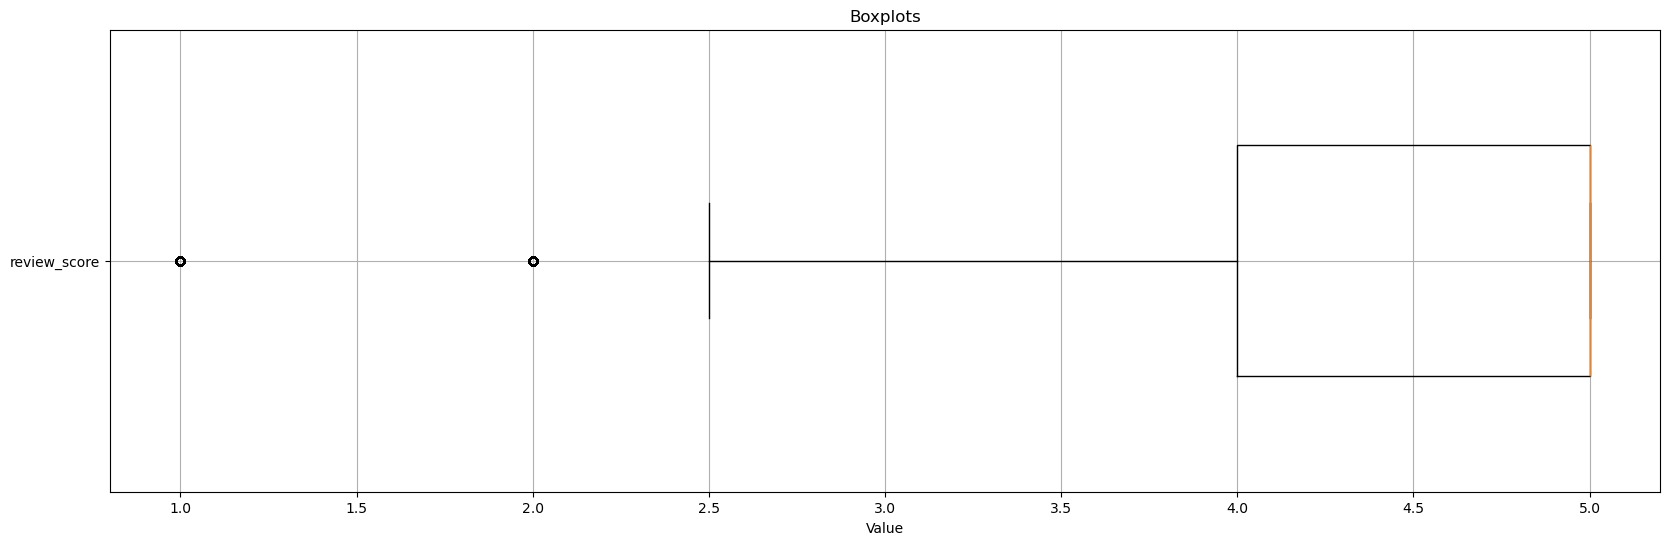

In [31]:
plot_boxplots(df, [col_name])

ГИСТОГРАММА РАСПРЕДЕЛЕНИЯ

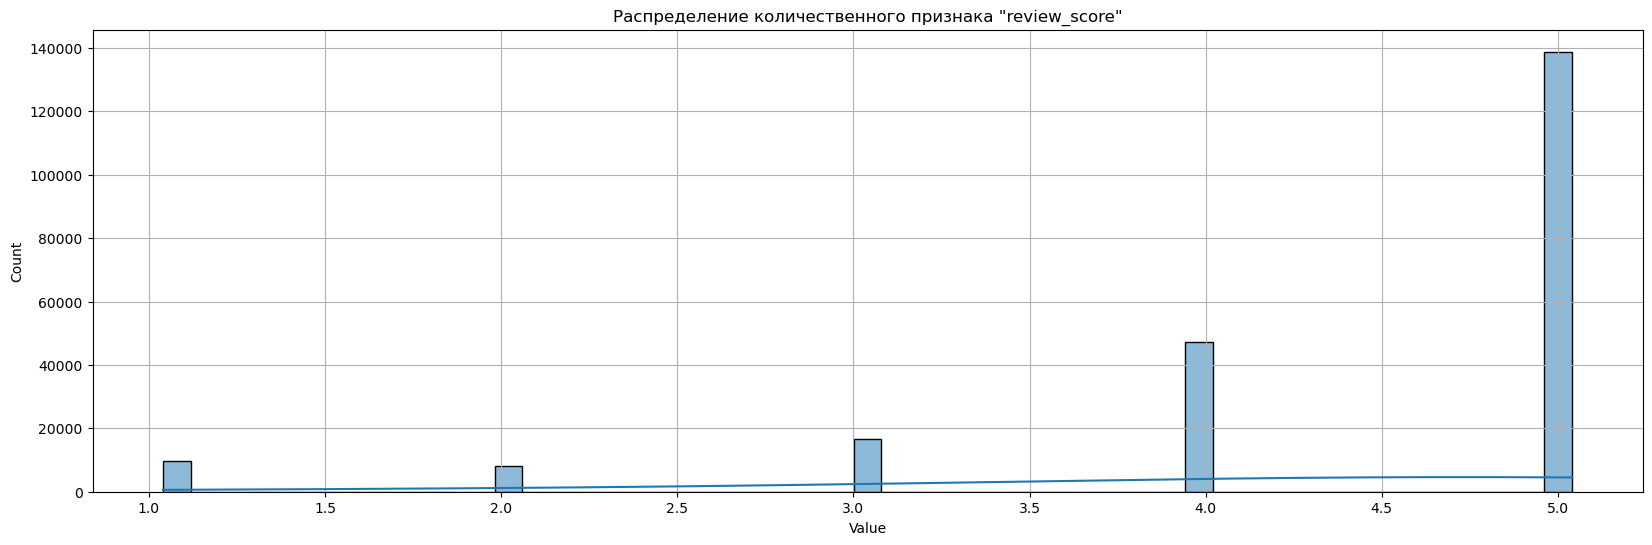

In [32]:
plot_quant_distribution(df, col_name, num_bins=50)

#### Анализ столбца `review_text`

Данный столбец содержит текст отзыва и представляет собой **текстовой признак**. Проанализируем текста и наличие пропущенных значений.

In [33]:
col_name = "review_text"
df.select(col_name).orderBy(col_name, ascending=False).show(10)
df.select(col_name).orderBy(col_name, ascending=True).show(10)

+--------------------+
|         review_text|
+--------------------+
|~~~This book is a...|
|~~D.J. Nold recei...|
|~Very phenomenal....|
|~On Power: The Na...|
|~On Power: The Na...|
|~I read this book...|
|~Catlin Andrews l...|
|~Based on the tit...|
|~* 4.5 Stars *~El...|
|~&lt;p~ own cabin...|
+--------------------+
only showing top 10 rows

+--------------------+
|         review_text|
+--------------------+
|!After having rea...|
|           "" ""Dune|
|"" ""House of Man...|
|    "" A Love Story"|
|       "" A Slithery|
|"" BUT STILL A HE...|
|"" BUT STILL HAS ...|
|"" But Generally ...|
|      "" Is Great !"|
|"" USING FRIENDSH...|
+--------------------+
only showing top 10 rows



In [34]:
count_nulls(data=df, column_name=col_name)

Число колонок с NULL: 0 (0.00%)


Анализ данных

In [41]:
from pyspark.sql.functions import (min as mn, max as mx, substring, size, split)

# Анализ до очистки
total_before = df.count()
print(f"Всего записей до очистки: {total_before:,}")

# Анализ пропущенных значений
null_count = df.filter(col("review_text").isNull()).count()
empty_count = df.filter((col("review_text") == "") | (col("review_text").isNull())).count()
whitespace_only = df.filter(trim(col("review_text")) == "").count()

print(f"Пропущенных значений (NULL): {null_count:,} ({null_count/total_before*100:.2f}%)")
print(f"Пустых строк: {empty_count:,} ({empty_count/total_before*100:.2f}%)")
print(f"Только пробелы: {whitespace_only:,} ({whitespace_only/total_before*100:.2f}%)")

# Анализ длины текста
df_with_length = df.withColumn("review_text_length", length(col("review_text")))

length_stats = df_with_length.select(
    mean("review_text_length").alias("avg_length"),
    stddev("review_text_length").alias("std_length"),
    mn("review_text_length").alias("min_length"),
    mx("review_text_length").alias("max_length"),
    count(when(col("review_text_length") == 0, True)).alias("zero_length")
).collect()[0]

print(f"\n=== СТАТИСТИКА ДЛИНЫ ТЕКСТА ===")
print(f"Средняя длина: {length_stats['avg_length']:.1f} символов")
print(f"Стандартное отклонение: {length_stats['std_length']:.1f}")
print(f"Минимальная длина: {length_stats['min_length']} символов")
print(f"Максимальная длина: {length_stats['max_length']} символов")
print(f"Текстов нулевой длины: {length_stats['zero_length']:,}")

# Анализ очень коротких текстов (возможный спам или мусор)
very_short = df_with_length.filter(col("review_text_length") < 10).count()
short = df_with_length.filter((col("review_text_length") >= 10) & (col("review_text_length") < 50)).count()
medium = df_with_length.filter((col("review_text_length") >= 50) & (col("review_text_length") < 200)).count()
long = df_with_length.filter(col("review_text_length") >= 200).count()

print(f"\n=== РАСПРЕДЕЛЕНИЕ ПО ДЛИНЕ ===")
print(f"Очень короткие (<10 символов): {very_short:,} ({very_short/total_before*100:.1f}%)")
print(f"Короткие (10-49 символов): {short:,} ({short/total_before*100:.1f}%)")
print(f"Средние (50-199 символов): {medium:,} ({medium/total_before*100:.1f}%)")
print(f"Длинные (200+ символов): {long:,} ({long/total_before*100:.1f}%)")

# Примеры текстов разной длины
print(f"\n=== ПРИМЕРЫ ТЕКСТОВ ===")

# Очень короткие тексты
if very_short > 0:
    print("Примеры очень коротких текстов:")
    df_with_length.filter(col("review_text_length") < 10) \
        .select("review_text", "review_text_length") \
        .limit(5) \
        .show(truncate=False)

# Очень длинные тексты
if long > 0:
    print("Примеры очень длинных текстов (первые 100 символов):")
    df_with_length.filter(col("review_text_length") >= 200) \
        .select(
            substring(col("review_text"), 1, 100).alias("text_preview"),
            "review_text_length"
        ) \
        .limit(3) \
        .show(truncate=False)

# Тексты с типичной длиной
typical = df_with_length.filter(
    (col("review_text_length") >= 50) & (col("review_text_length") <= 200)
)
if typical.count() > 0:
    print("Примеры текстов типичной длины:")
    typical.select(
        substring(col("review_text"), 1, 100).alias("text_preview"),
        "review_text_length"
    ).limit(3).show(truncate=False)

# Расширенный анализ текстовых особенностей
print(f"\n=== РАСШИРЕННЫЙ АНАЛИЗ ТЕКСТА ===")

df_with_analysis = df.withColumn(
    "contains_html", 
    col("review_text").rlike(r"&[a-z]+;")
).withColumn(
    "contains_url",
    col("review_text").rlike(r"https?://")
).withColumn(
    "word_count",
    size(split(trim(col("review_text")), "\\s+"))
)

# Статистика по словам
word_stats = df_with_analysis.select(
    mean("word_count").alias("avg_words"),
    stddev("word_count").alias("std_words"),
    mn("word_count").alias("min_words"),
    mx("word_count").alias("max_words")
).collect()[0]

print(f"Среднее количество слов: {word_stats['avg_words']:.1f}")
print(f"Мин. количество слов: {word_stats['min_words']}")
print(f"Макс. количество слов: {word_stats['max_words']}")

# Анализ HTML-сущностей и URL
html_count = df_with_analysis.filter(col("contains_html") == True).count()
url_count = df_with_analysis.filter(col("contains_url") == True).count()

print(f"Текстов с HTML-сущностями: {html_count:,} ({html_count/total_before*100:.1f}%)")
print(f"Текстов с URL: {url_count:,} ({url_count/total_before*100:.1f}%)")

# Примеры с HTML и URL
if html_count > 0:
    print("\nПримеры текстов с HTML-сущностями:")
    df_with_analysis.filter(col("contains_html") == True) \
        .select("review_text") \
        .limit(3) \
        .show(truncate=False)

if url_count > 0:
    print("Примеры текстов с URL:")
    df_with_analysis.filter(col("contains_url") == True) \
        .select("review_text") \
        .limit(3) \
        .show(truncate=False)

Всего записей до очистки: 220,276
Пропущенных значений (NULL): 0 (0.00%)
Пустых строк: 0 (0.00%)
Только пробелы: 0 (0.00%)

=== СТАТИСТИКА ДЛИНЫ ТЕКСТА ===
Средняя длина: 730.4 символов
Стандартное отклонение: 735.8
Минимальная длина: 1 символов
Максимальная длина: 16941 символов
Текстов нулевой длины: 0

=== РАСПРЕДЕЛЕНИЕ ПО ДЛИНЕ ===
Очень короткие (<10 символов): 82 (0.0%)
Короткие (10-49 символов): 1,632 (0.7%)
Средние (50-199 символов): 32,604 (14.8%)
Длинные (200+ символов): 185,958 (84.4%)

=== ПРИМЕРЫ ТЕКСТОВ ===
Примеры очень коротких текстов:
+-----------+------------------+
|review_text|review_text_length|
+-----------+------------------+
|.          |1                 |
|goo        |3                 |
|Maine"""   |8                 |
|Engaging   |8                 |
|"""Love    |7                 |
+-----------+------------------+

Примеры очень длинных текстов (первые 100 символов):
+-----------------------------------------------------------------------------------------

#### Анализ столбца `review_summary`

Данный столбец содержит информацию об заголовках отзывыв и представляет собой **текстовой признак**. Проанализируем заголовки и наличие пропущенных значений.

In [42]:
col_name = "review_summary"
df.select(col_name).orderBy(col_name, ascending=False).show(10)
df.select(col_name).orderBy(col_name, ascending=True).show(10)

+--------------------+
|      review_summary|
+--------------------+
|~~incredibly fun ...|
|~~Spooky and intr...|
|~gourmet & specia...|
|~a life-long coll...|
|~Tis lovlier than...|
|~TOTALLY AN INSPI...|
|~THE LOVING NEVER...|
|      ~Sweet Dreams~|
|       ~Phenomenal!~|
|~BEWARE IS CENSOR...|
+--------------------+
only showing top 10 rows

+--------------------+
|      review_summary|
+--------------------+
|                NULL|
|                NULL|
|                NULL|
|                   !|
|          ! SUPERB !|
|                  !!|
|                 !!!|
|                 !!!|
|!!!!!!!!!!!! The ...|
|!!!!!!The Worlds ...|
+--------------------+
only showing top 10 rows



In [43]:
count_nulls(data=df, column_name=col_name)

Число колонок с NULL: 3 (0.00%)


Анализ данных

In [44]:
from pyspark.sql.functions import (min as mn, max as mx, substring, size, split)

# Анализ до очистки
total_before = df.count()
print(f"Всего записей до очистки: {total_before:,}")

# Анализ пропущенных значений
null_count = df.filter(col("review_text").isNull()).count()
empty_count = df.filter((col("review_text") == "") | (col("review_text").isNull())).count()
whitespace_only = df.filter(trim(col("review_text")) == "").count()

print(f"Пропущенных значений (NULL): {null_count:,} ({null_count/total_before*100:.2f}%)")
print(f"Пустых строк: {empty_count:,} ({empty_count/total_before*100:.2f}%)")
print(f"Только пробелы: {whitespace_only:,} ({whitespace_only/total_before*100:.2f}%)")

# Анализ длины текста
df_with_length = df.withColumn("review_text_length", length(col("review_text")))

length_stats = df_with_length.select(
    mean("review_text_length").alias("avg_length"),
    stddev("review_text_length").alias("std_length"),
    mn("review_text_length").alias("min_length"),
    mx("review_text_length").alias("max_length"),
    count(when(col("review_text_length") == 0, True)).alias("zero_length")
).collect()[0]

print(f"\n=== СТАТИСТИКА ДЛИНЫ ТЕКСТА ===")
print(f"Средняя длина: {length_stats['avg_length']:.1f} символов")
print(f"Стандартное отклонение: {length_stats['std_length']:.1f}")
print(f"Минимальная длина: {length_stats['min_length']} символов")
print(f"Максимальная длина: {length_stats['max_length']} символов")
print(f"Текстов нулевой длины: {length_stats['zero_length']:,}")

# Анализ очень коротких текстов (возможный спам или мусор)
very_short = df_with_length.filter(col("review_text_length") < 10).count()
short = df_with_length.filter((col("review_text_length") >= 10) & (col("review_text_length") < 50)).count()
medium = df_with_length.filter((col("review_text_length") >= 50) & (col("review_text_length") < 200)).count()
long = df_with_length.filter(col("review_text_length") >= 200).count()

print(f"\n=== РАСПРЕДЕЛЕНИЕ ПО ДЛИНЕ ===")
print(f"Очень короткие (<10 символов): {very_short:,} ({very_short/total_before*100:.1f}%)")
print(f"Короткие (10-49 символов): {short:,} ({short/total_before*100:.1f}%)")
print(f"Средние (50-199 символов): {medium:,} ({medium/total_before*100:.1f}%)")
print(f"Длинные (200+ символов): {long:,} ({long/total_before*100:.1f}%)")

# Примеры текстов разной длины
print(f"\n=== ПРИМЕРЫ ТЕКСТОВ ===")

# Очень короткие тексты
if very_short > 0:
    print("Примеры очень коротких текстов:")
    df_with_length.filter(col("review_text_length") < 10) \
        .select("review_text", "review_text_length") \
        .limit(5) \
        .show(truncate=False)

# Очень длинные тексты
if long > 0:
    print("Примеры очень длинных текстов (первые 100 символов):")
    df_with_length.filter(col("review_text_length") >= 200) \
        .select(
            substring(col("review_text"), 1, 100).alias("text_preview"),
            "review_text_length"
        ) \
        .limit(3) \
        .show(truncate=False)

# Тексты с типичной длиной
typical = df_with_length.filter(
    (col("review_text_length") >= 50) & (col("review_text_length") <= 200)
)
if typical.count() > 0:
    print("Примеры текстов типичной длины:")
    typical.select(
        substring(col("review_text"), 1, 100).alias("text_preview"),
        "review_text_length"
    ).limit(3).show(truncate=False)

# Расширенный анализ текстовых особенностей
print(f"\n=== РАСШИРЕННЫЙ АНАЛИЗ ТЕКСТА ===")

df_with_analysis = df.withColumn(
    "contains_html", 
    col("review_text").rlike(r"&[a-z]+;")
).withColumn(
    "contains_url",
    col("review_text").rlike(r"https?://")
).withColumn(
    "word_count",
    size(split(trim(col("review_text")), "\\s+"))
)

# Статистика по словам
word_stats = df_with_analysis.select(
    mean("word_count").alias("avg_words"),
    stddev("word_count").alias("std_words"),
    mn("word_count").alias("min_words"),
    mx("word_count").alias("max_words")
).collect()[0]

print(f"Среднее количество слов: {word_stats['avg_words']:.1f}")
print(f"Мин. количество слов: {word_stats['min_words']}")
print(f"Макс. количество слов: {word_stats['max_words']}")

# Анализ HTML-сущностей и URL
html_count = df_with_analysis.filter(col("contains_html") == True).count()
url_count = df_with_analysis.filter(col("contains_url") == True).count()

print(f"Текстов с HTML-сущностями: {html_count:,} ({html_count/total_before*100:.1f}%)")
print(f"Текстов с URL: {url_count:,} ({url_count/total_before*100:.1f}%)")

# Примеры с HTML и URL
if html_count > 0:
    print("\nПримеры текстов с HTML-сущностями:")
    df_with_analysis.filter(col("contains_html") == True) \
        .select("review_text") \
        .limit(3) \
        .show(truncate=False)

if url_count > 0:
    print("Примеры текстов с URL:")
    df_with_analysis.filter(col("contains_url") == True) \
        .select("review_text") \
        .limit(3) \
        .show(truncate=False)

Всего записей до очистки: 220,276
Пропущенных значений (NULL): 0 (0.00%)
Пустых строк: 0 (0.00%)
Только пробелы: 0 (0.00%)

=== СТАТИСТИКА ДЛИНЫ ТЕКСТА ===
Средняя длина: 730.4 символов
Стандартное отклонение: 735.8
Минимальная длина: 1 символов
Максимальная длина: 16941 символов
Текстов нулевой длины: 0

=== РАСПРЕДЕЛЕНИЕ ПО ДЛИНЕ ===
Очень короткие (<10 символов): 82 (0.0%)
Короткие (10-49 символов): 1,632 (0.7%)
Средние (50-199 символов): 32,604 (14.8%)
Длинные (200+ символов): 185,958 (84.4%)

=== ПРИМЕРЫ ТЕКСТОВ ===
Примеры очень коротких текстов:
+-----------+------------------+
|review_text|review_text_length|
+-----------+------------------+
|.          |1                 |
|goo        |3                 |
|Maine"""   |8                 |
|Engaging   |8                 |
|"""Love    |7                 |
+-----------+------------------+

Примеры очень длинных текстов (первые 100 символов):
+-----------------------------------------------------------------------------------------

#### Анализ столбца `review_helpfulness`

Данный столбец содержит информацию об полезности отзыва и представляет собой **количественный (составной)**. Проанализируем полезность отзывов и наличие пропущенных значений, используя поля numerator, denominator и ratio.

Анализ numerator

In [46]:
# Базовая статистика
numerator_stats = df.select(
    count("helpfulness_numerator").alias("total"),
    mean("helpfulness_numerator").alias("avg"),
    stddev("helpfulness_numerator").alias("std"),
    mn("helpfulness_numerator").alias("min"),
    mx("helpfulness_numerator").alias("max"),
    count(when(col("helpfulness_numerator").isNull(), True)).alias("null_count"),
    count(when(col("helpfulness_numerator") == 0, True)).alias("zero_count")
).collect()[0]

print(f"Всего значений: {numerator_stats['total']:,}")
print(f"Пропущенных: {numerator_stats['null_count']:,} ({numerator_stats['null_count']/df.count()*100:.2f}%)")
print(f"Среднее: {numerator_stats['avg']:.2f}")
print(f"Стандартное отклонение: {numerator_stats['std']:.2f}")
print(f"Минимум: {numerator_stats['min']}")
print(f"Максимум: {numerator_stats['max']}")
print(f"Нулевых значений: {numerator_stats['zero_count']:,} ({numerator_stats['zero_count']/numerator_stats['total']*100:.1f}%)")

# Распределение по диапазонам
numerator_ranges = df.withColumn(
    "numerator_range",
    when(col("helpfulness_numerator") == 0, "0")
    .when(col("helpfulness_numerator") <= 5, "1-5")
    .when(col("helpfulness_numerator") <= 10, "6-10")
    .when(col("helpfulness_numerator") <= 20, "11-20")
    .when(col("helpfulness_numerator") <= 50, "21-50")
    .when(col("helpfulness_numerator") <= 100, "51-100")
    .otherwise("100+")
).groupBy("numerator_range").count().orderBy("numerator_range")

print("\nРАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ:")
numerator_ranges.show()

# Топ значений
print("ТОП-10 НАИБОЛЕЕ ПОЛЕЗНЫХ ОТЗЫВОВ:")
df.orderBy(desc("helpfulness_numerator")) \
  .select("helpfulness_numerator", "helpfulness_denominator", "helpfulness_ratio", "review_summary") \
  .limit(10) \
  .show(truncate=False)

Всего значений: 220,276
Пропущенных: 0 (0.00%)
Среднее: 8.31
Стандартное отклонение: 15.65
Минимум: 0
Максимум: 742
Нулевых значений: 46,197 (21.0%)

РАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ:
+---------------+-----+
|numerator_range|count|
+---------------+-----+
|              0|46197|
|            1-5|89803|
|           100+|  900|
|          11-20|27587|
|          21-50|18070|
|         51-100| 3754|
|           6-10|33965|
+---------------+-----+

ТОП-10 НАИБОЛЕЕ ПОЛЕЗНЫХ ОТЗЫВОВ:
+---------------------+-----------------------+------------------+---------------------------------------------------------+
|helpfulness_numerator|helpfulness_denominator|helpfulness_ratio |review_summary                                           |
+---------------------+-----------------------+------------------+---------------------------------------------------------+
|742                  |770                    |0.9636363636363636|A controversial masterpiece                              |
|703                  

Анализ denominator

In [47]:
# Базовая статистика
denominator_stats = df.select(
    count("helpfulness_denominator").alias("total"),
    mean("helpfulness_denominator").alias("avg"),
    stddev("helpfulness_denominator").alias("std"),
    mn("helpfulness_denominator").alias("min"),
    mx("helpfulness_denominator").alias("max"),
    count(when(col("helpfulness_denominator").isNull(), True)).alias("null_count"),
    count(when(col("helpfulness_denominator") == 0, True)).alias("zero_count")
).collect()[0]

print(f"Всего значений: {denominator_stats['total']:,}")
print(f"Пропущенных: {denominator_stats['null_count']:,} ({denominator_stats['null_count']/df.count()*100:.2f}%)")
print(f"Среднее: {denominator_stats['avg']:.2f}")
print(f"Стандартное отклонение: {denominator_stats['std']:.2f}")
print(f"Минимум: {denominator_stats['min']}")
print(f"Максимум: {denominator_stats['max']}")
print(f"Нулевых значений: {denominator_stats['zero_count']:,} ({denominator_stats['zero_count']/denominator_stats['total']*100:.1f}%)")

# Распределение по диапазонам
denominator_ranges = df.withColumn(
    "denominator_range",
    when(col("helpfulness_denominator") == 0, "0")
    .when(col("helpfulness_denominator") <= 5, "1-5")
    .when(col("helpfulness_denominator") <= 10, "6-10")
    .when(col("helpfulness_denominator") <= 20, "11-20")
    .when(col("helpfulness_denominator") <= 50, "21-50")
    .when(col("helpfulness_denominator") <= 100, "51-100")
    .otherwise("100+")
).groupBy("denominator_range").count().orderBy("denominator_range")

print("\nРАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ:")
denominator_ranges.show()

# Анализ отзывов без оценок полезности
no_votes = df.filter(col("helpfulness_denominator") == 0).count()
with_votes = df.filter(col("helpfulness_denominator") > 0).count()
total_with_values = no_votes + with_votes

print(f"\nАНАЛИЗ ОЦЕНОК ПОЛЕЗНОСТИ:")
print(f"Отзывов без оценок полезности: {no_votes:,} ({no_votes/total_with_values*100:.1f}%)")
print(f"Отзывов с оценками полезности: {with_votes:,} ({with_votes/total_with_values*100:.1f}%)")

Всего значений: 220,276
Пропущенных: 0 (0.00%)
Среднее: 9.21
Стандартное отклонение: 16.65
Минимум: 0
Максимум: 770
Нулевых значений: 39,566 (18.0%)

РАСПРЕДЕЛЕНИЕ ПО ДИАПАЗОНАМ:
+-----------------+-----+
|denominator_range|count|
+-----------------+-----+
|                0|39566|
|              1-5|88470|
|             100+| 1054|
|            11-20|30331|
|            21-50|20367|
|           51-100| 4380|
|             6-10|36108|
+-----------------+-----+


АНАЛИЗ ОЦЕНОК ПОЛЕЗНОСТИ:
Отзывов без оценок полезности: 39,566 (18.0%)
Отзывов с оценками полезности: 180,710 (82.0%)


Анализ ratio

In [49]:
# Базовая статистика
ratio_stats = df.filter(col("helpfulness_ratio").isNotNull()).select(
    count("helpfulness_ratio").alias("total"),
    mean("helpfulness_ratio").alias("avg"),
    stddev("helpfulness_ratio").alias("std"),
    mn("helpfulness_ratio").alias("min"),
    mx("helpfulness_ratio").alias("max"),
    count(when(col("helpfulness_ratio").isNull(), True)).alias("null_count")
).collect()[0]

print(f"Всего значений: {ratio_stats['total']:,}")
print(f"Пропущенных: {ratio_stats['null_count']:,}")
print(f"Среднее: {ratio_stats['avg']:.3f}")
print(f"Стандартное отклонение: {ratio_stats['std']:.3f}")
print(f"Минимум: {ratio_stats['min']:.3f}")
print(f"Максимум: {ratio_stats['max']:.3f}")

# Распределение по категориям полезности
helpfulness_categories = df.withColumn(
    "helpfulness_category",
    when(col("helpfulness_denominator") == 0, "Без оценок")
    .when(col("helpfulness_ratio") == 1.0, "Идеально полезный (100%)")
    .when(col("helpfulness_ratio") >= 0.8, "Очень полезный (80-99%)")
    .when(col("helpfulness_ratio") >= 0.6, "Полезный (60-79%)")
    .when(col("helpfulness_ratio") >= 0.4, "Умеренно полезный (40-59%)")
    .when(col("helpfulness_ratio") >= 0.2, "Мало полезный (20-39%)")
    .when(col("helpfulness_ratio") > 0.0, "Слабо полезный (1-19%)")
    .when(col("helpfulness_ratio") == 0.0, "Бесполезный (0%)")
    .otherwise("Не определено")
).groupBy("helpfulness_category").count().orderBy(desc("count"))

print("\nРАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ ПОЛЕЗНОСТИ:")
helpfulness_categories.show()

# Анализ крайних значений
perfect_helpful = df.filter(col("helpfulness_ratio") == 1.0).count()
not_helpful = df.filter(col("helpfulness_ratio") == 0.0).count()
controversial = df.filter((col("helpfulness_ratio") > 0.4) & (col("helpfulness_ratio") < 0.6)).count()

print(f"\nКРАЙНИЕ ЗНАЧЕНИЯ:")
print(f"Идеально полезные (100%): {perfect_helpful:,} ({perfect_helpful/ratio_stats['total']*100:.1f}%)")
print(f"Абсолютно бесполезные (0%): {not_helpful:,} ({not_helpful/ratio_stats['total']*100:.1f}%)")
print(f"Противоречивые (40-60%): {controversial:,} ({controversial/ratio_stats['total']*100:.1f}%)")

Всего значений: 220,276
Пропущенных: 0
Среднее: 0.723
Стандартное отклонение: 0.402
Минимум: 0.000
Максимум: 1.000

РАСПРЕДЕЛЕНИЕ ПО КАТЕГОРИЯМ ПОЛЕЗНОСТИ:
+--------------------+------+
|helpfulness_category| count|
+--------------------+------+
|Идеально полезный...|110330|
|          Без оценок| 39566|
|Очень полезный (8...| 39346|
|   Полезный (60-79%)| 12453|
|Умеренно полезный...|  7011|
|    Бесполезный (0%)|  6631|
|Мало полезный (20...|  3597|
|Слабо полезный (1...|  1342|
+--------------------+------+


КРАЙНИЕ ЗНАЧЕНИЯ:
Идеально полезные (100%): 110,330 (50.1%)
Абсолютно бесполезные (0%): 46,197 (21.0%)
Противоречивые (40-60%): 6,523 (3.0%)


Сводный анализ 3х параметров

In [50]:
# Корреляция между полями
corr_numerator_denominator = df.stat.corr("helpfulness_numerator", "helpfulness_denominator")
corr_numerator_ratio = df.stat.corr("helpfulness_numerator", "helpfulness_ratio")
corr_denominator_ratio = df.stat.corr("helpfulness_denominator", "helpfulness_ratio")

print(f"КОРРЕЛЯЦИИ:")
print(f"Числитель vs Знаменатель: {corr_numerator_denominator:.3f}")
print(f"Числитель vs Коэффициент: {corr_numerator_ratio:.3f}")
print(f"Знаменатель vs Коэффициент: {corr_denominator_ratio:.3f}")

# Анализ аномалий
print(f"\nАНАЛИЗ АНОМАЛИЙ:")
# Случаи когда числитель больше знаменателя
numerator_gt_denominator = df.filter(col("helpfulness_numerator") > col("helpfulness_denominator")).count()
print(f"Числитель > Знаменателя: {numerator_gt_denominator}")

# Случаи с высоким коэффициентом но малым количеством голосов
high_ratio_low_votes = df.filter(
    (col("helpfulness_ratio") >= 0.9) & 
    (col("helpfulness_denominator") <= 2)
).count()
print(f"Высокий коэффициент при малом количестве голосов: {high_ratio_low_votes}")

# Примеры различных типов отзывов
print(f"\nПРИМЕРЫ РАЗЛИЧНЫХ ТИПОВ ОТЗЫВОВ:")

print("1. Самые полезные отзывы (высокий коэффициент + много голосов):")
df.filter(
    (col("helpfulness_ratio") == 1.0) & 
    (col("helpfulness_denominator") >= 10)
).select(
    "helpfulness_numerator", "helpfulness_denominator", "helpfulness_ratio", "review_summary"
).limit(3).show(truncate=False)

print("2. Противоречивые отзывы (коэффициент около 50%):")
df.filter(
    (col("helpfulness_ratio") >= 0.45) & 
    (col("helpfulness_ratio") <= 0.55) &
    (col("helpfulness_denominator") >= 5)
).select(
    "helpfulness_numerator", "helpfulness_denominator", "helpfulness_ratio", "review_summary"
).limit(3).show(truncate=False)

print("3. Отзывы с большим количеством голосов:")
df.orderBy(desc("helpfulness_denominator")) \
  .select("helpfulness_numerator", "helpfulness_denominator", "helpfulness_ratio", "review_summary") \
  .limit(3) \
  .show(truncate=False)

КОРРЕЛЯЦИИ:
Числитель vs Знаменатель: 0.980
Числитель vs Коэффициент: 0.288
Знаменатель vs Коэффициент: 0.247

АНАЛИЗ АНОМАЛИЙ:
Числитель > Знаменателя: 0
Высокий коэффициент при малом количестве голосов: 38391

ПРИМЕРЫ РАЗЛИЧНЫХ ТИПОВ ОТЗЫВОВ:
1. Самые полезные отзывы (высокий коэффициент + много голосов):
+---------------------+-----------------------+-----------------+------------------------+
|helpfulness_numerator|helpfulness_denominator|helpfulness_ratio|review_summary          |
+---------------------+-----------------------+-----------------+------------------------+
|11                   |11                     |1.0              |a great 1st book        |
|26                   |26                     |1.0              |Disappointing conclusion|
|13                   |13                     |1.0              |Easy to Enjoy           |
+---------------------+-----------------------+-----------------+------------------------+

2. Противоречивые отзывы (коэффициент около 50%):
+--

Визуализация

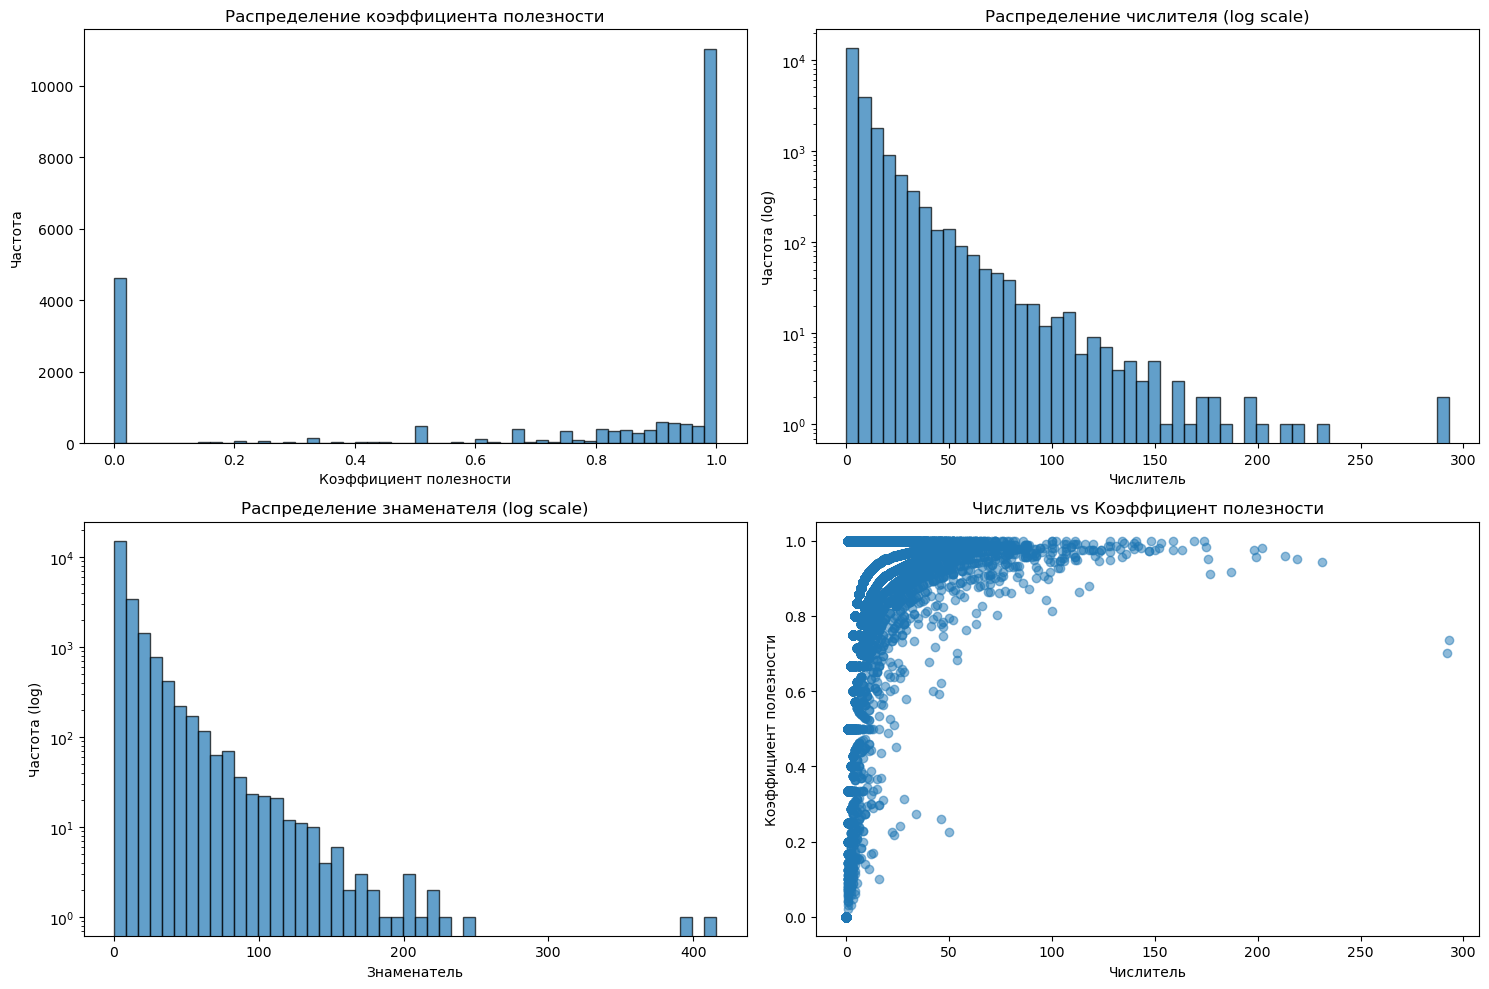

In [51]:
# Для визуализации возьмем sample данных
sample_df = df.sample(0.1).toPandas()

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Распределение helpfulness_ratio
axes[0, 0].hist(sample_df['helpfulness_ratio'].dropna(), bins=50, alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Распределение коэффициента полезности')
axes[0, 0].set_xlabel('Коэффициент полезности')
axes[0, 0].set_ylabel('Частота')

# 2. Распределение числителя (логарифмическая шкала)
axes[0, 1].hist(sample_df['helpfulness_numerator'].dropna(), bins=50, alpha=0.7, edgecolor='black', log=True)
axes[0, 1].set_title('Распределение числителя (log scale)')
axes[0, 1].set_xlabel('Числитель')
axes[0, 1].set_ylabel('Частота (log)')

# 3. Распределение знаменателя (логарифмическая шкала)
axes[1, 0].hist(sample_df['helpfulness_denominator'].dropna(), bins=50, alpha=0.7, edgecolor='black', log=True)
axes[1, 0].set_title('Распределение знаменателя (log scale)')
axes[1, 0].set_xlabel('Знаменатель')
axes[1, 0].set_ylabel('Частота (log)')

# 4. scatter plot: числитель vs коэффициент
axes[1, 1].scatter(sample_df['helpfulness_numerator'], sample_df['helpfulness_ratio'], alpha=0.5)
axes[1, 1].set_title('Числитель vs Коэффициент полезности')
axes[1, 1].set_xlabel('Числитель')
axes[1, 1].set_ylabel('Коэффициент полезности')

plt.tight_layout()
plt.show()

#### Анализ столбца `review_time`

Данный столбец содержит информацию о временной метке отзыва и представляет собой **временной признак**. Проанализируем распределение меток и наличие пропущенных значений.

In [52]:
col_name = "review_time"
df.select(col_name).orderBy(col_name, ascending=False).show(10)
df.select(col_name).orderBy(col_name, ascending=True).show(10)

+-----------+
|review_time|
+-----------+
| 1362355200|
| 1362268800|
| 1362268800|
| 1362268800|
| 1362268800|
| 1362268800|
| 1362268800|
| 1362268800|
| 1362268800|
| 1362268800|
+-----------+
only showing top 10 rows

+-----------+
|review_time|
+-----------+
|         -1|
|         -1|
|  806284800|
|  806284800|
|  806371200|
|  806371200|
|  808531200|
|  811641600|
|  812419200|
|  813801600|
+-----------+
only showing top 10 rows



Статистика

In [54]:
# Базовая статистика
time_stats = df.select(
    count("review_time").alias("total"),
    mean("review_time").alias("avg"),
    stddev("review_time").alias("std"),
    mn("review_time").alias("min"),
    mx("review_time").alias("max"),
    count(when(col("review_time").isNull(), True)).alias("null_count")
).collect()[0]

print(f"Всего временных меток: {time_stats['total']:,}")
print(f"Пропущенных: {time_stats['null_count']:,} ({time_stats['null_count']/df.count()*100:.2f}%)")
print(f"Среднее значение: {time_stats['avg']:,.0f}")
print(f"Стандартное отклонение: {time_stats['std']:,.0f}")
print(f"Минимальная метка: {time_stats['min']}")
print(f"Максимальная метка: {time_stats['max']}")

Всего временных меток: 220,276
Пропущенных: 0 (0.00%)
Среднее значение: 1,098,443,018
Стандартное отклонение: 134,691,318
Минимальная метка: -1
Максимальная метка: 1362355200


Преобразование дат

In [59]:
from pyspark.sql.functions import (from_unixtime, year, date_format)

# Преобразуем timestamp в читаемые форматы
df_with_dates = df.withColumn(
    "review_date", 
    from_unixtime(col("review_time")).cast("date")
).withColumn(
    "review_datetime",
    from_unixtime(col("review_time"))
).withColumn(
    "review_year", 
    year(col("review_date"))
).withColumn(
    "review_month",
    date_format(col("review_date"), "yyyy-MM")
).withColumn(
    "review_day_of_week",
    date_format(col("review_date"), "EEEE")
)

# Проверяем преобразование
print("\n=== ПРИМЕРЫ ПРЕОБРАЗОВАННЫХ ДАТ ===")
df_with_dates.select(
    "review_time", 
    "review_datetime", 
    "review_date",
    "review_year",
    "review_month",
    "review_day_of_week"
).limit(10).show(truncate=False)


=== ПРИМЕРЫ ПРЕОБРАЗОВАННЫХ ДАТ ===
+-----------+-------------------+-----------+-----------+------------+------------------+
|review_time|review_datetime    |review_date|review_year|review_month|review_day_of_week|
+-----------+-------------------+-----------+-----------+------------+------------------+
|1057276800 |2003-07-04 00:00:00|2003-07-04 |2003       |2003-07     |Friday            |
|1277942400 |2010-07-01 00:00:00|2010-07-01 |2010       |2010-07     |Thursday          |
|1089936000 |2004-07-16 00:00:00|2004-07-16 |2004       |2004-07     |Friday            |
|1011398400 |2002-01-19 00:00:00|2002-01-19 |2002       |2002-01     |Saturday          |
|1128384000 |2005-10-04 00:00:00|2005-10-04 |2005       |2005-10     |Tuesday           |
|1184198400 |2007-07-12 00:00:00|2007-07-12 |2007       |2007-07     |Thursday          |
|1127260800 |2005-09-21 00:00:00|2005-09-21 |2005       |2005-09     |Wednesday         |
|1272412800 |2010-04-28 00:00:00|2010-04-28 |2010       |2010-0

Анализ по годам

Количество отзывов по годам:
+-----------+------------+------------------+
|review_year|review_count|        avg_rating|
+-----------+------------+------------------+
|       1969|           2|               5.0|
|       1995|          18| 4.666666666666667|
|       1996|         326| 4.711656441717792|
|       1997|        2551|  4.60015680125441|
|       1998|        7808| 4.494364754098361|
|       1999|       15082| 4.416191486540247|
|       2000|       27874| 4.433701657458563|
|       2001|       18652| 4.398938451640575|
|       2002|       15876| 4.366717057193248|
|       2003|       15742| 4.356371490280778|
|       2004|       16560| 4.366485507246376|
|       2005|       20701| 4.351239070576301|
|       2006|       14647| 4.303543387724448|
|       2007|       10390| 4.238594802694899|
|       2008|        8567| 4.247577915256215|
|       2009|        9019| 4.279742765273312|
|       2010|        9322|4.2180862475863545|
|       2011|        9308| 4.219810915341641|
|    

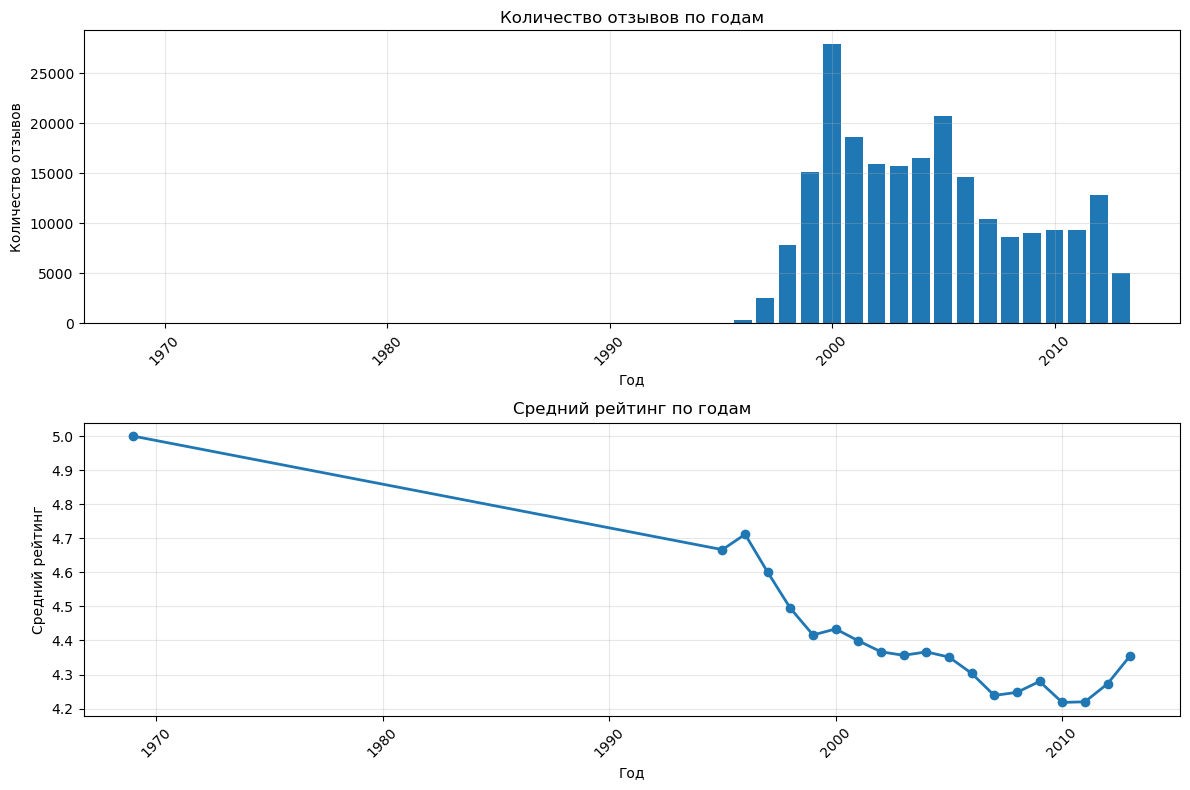

In [60]:
from pyspark.sql.functions import avg

yearly_stats = df_with_dates.filter(col("review_year").isNotNull()) \
    .groupBy("review_year") \
    .agg(
        count("*").alias("review_count"),
        avg("review_score").alias("avg_rating")
    ) \
    .orderBy("review_year")

print("Количество отзывов по годам:")
yearly_stats.show()

# Визуализация трендов
yearly_pd = yearly_stats.toPandas()

plt.figure(figsize=(12, 8))

plt.subplot(2, 1, 1)
plt.bar(yearly_pd['review_year'], yearly_pd['review_count'])
plt.title('Количество отзывов по годам')
plt.xlabel('Год')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.subplot(2, 1, 2)
plt.plot(yearly_pd['review_year'], yearly_pd['avg_rating'], marker='o', linewidth=2, markersize=6)
plt.title('Средний рейтинг по годам')
plt.xlabel('Год')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Анализ по месяцам

In [61]:
# Находим последний полный год с данными
last_year = yearly_pd[yearly_pd['review_count'] > 0]['review_year'].max()
print(f"Анализ за последний полный год: {last_year}")

monthly_stats = df_with_dates.filter(col("review_year") == last_year) \
    .groupBy("review_month") \
    .agg(
        count("*").alias("review_count"),
        avg("review_score").alias("avg_rating")
    ) \
    .orderBy("review_month")

print(f"Распределение по месяцам за {last_year} год:")
monthly_stats.show()

# Сезонность по месяцам (все годы)
monthly_all_years = df_with_dates.filter(col("review_month").isNotNull()) \
    .withColumn("month_only", substring(col("review_month"), 6, 2)) \
    .groupBy("month_only") \
    .agg(
        count("*").alias("review_count"),
        avg("review_score").alias("avg_rating")
    ) \
    .orderBy("month_only")

print("Сезонность по месяцам (все годы):")
monthly_all_years.show()

Анализ за последний полный год: 2013
Распределение по месяцам за 2013 год:
+------------+------------+-----------------+
|review_month|review_count|       avg_rating|
+------------+------------+-----------------+
|     2013-01|        2698| 4.35063009636768|
|     2013-02|        2250|4.358222222222222|
|     2013-03|          73|4.424657534246576|
+------------+------------+-----------------+

Сезонность по месяцам (все годы):
+----------+------------+------------------+
|month_only|review_count|        avg_rating|
+----------+------------+------------------+
|        01|       21854| 4.330831884323236|
|        02|       19165|4.3468823375945735|
|        03|       19354| 4.353156970135372|
|        04|       18154|4.3550732620909995|
|        05|       18120| 4.359326710816777|
|        06|       17537| 4.353196099674973|
|        07|       17707| 4.361382504094426|
|        08|       17675|  4.33052333804809|
|        09|       16798| 4.336111441838314|
|        10|       17448| 4.

Анализ по неделям

In [62]:
day_of_week_stats = df_with_dates.filter(col("review_day_of_week").isNotNull()) \
    .groupBy("review_day_of_week") \
    .agg(
        count("*").alias("review_count"),
        avg("review_score").alias("avg_rating")
    )

# Сортируем по порядку дней недели
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_of_week_stats = day_of_week_stats \
    .withColumn("day_order", 
        when(col("review_day_of_week") == "Monday", 1)
        .when(col("review_day_of_week") == "Tuesday", 2)
        .when(col("review_day_of_week") == "Wednesday", 3)
        .when(col("review_day_of_week") == "Thursday", 4)
        .when(col("review_day_of_week") == "Friday", 5)
        .when(col("review_day_of_week") == "Saturday", 6)
        .when(col("review_day_of_week") == "Sunday", 7)
    ) \
    .orderBy("day_order")

print("Распределение по дням недели:")
day_of_week_stats.select("review_day_of_week", "review_count", "avg_rating").show()

Распределение по дням недели:
+------------------+------------+-----------------+
|review_day_of_week|review_count|       avg_rating|
+------------------+------------+-----------------+
|            Monday|       33980|4.339994114184814|
|           Tuesday|       33704|4.339188226916686|
|         Wednesday|       33486|4.349101116884668|
|          Thursday|       32114| 4.35467397396774|
|            Friday|       30293|4.356683062093553|
|          Saturday|       27740| 4.35746214852199|
|            Sunday|       28959|4.357505438723713|
+------------------+------------+-----------------+



Анализ временных паттернов

In [65]:
# Период покрытия данных
date_range = df_with_dates.select(
    mn("review_date").alias("first_review"),
    mx("review_date").alias("last_review")
).collect()[0]

print(f"Период покрытия данных:")
print(f"Первый отзыв: {date_range['first_review']}")
print(f"Последний отзыв: {date_range['last_review']}")

# Количество дней с отзывами
days_with_reviews = df_with_dates.select("review_date").distinct().count()
total_days = (date_range['last_review'] - date_range['first_review']).days

print(f"Дней с отзывами: {days_with_reviews} из {total_days} ({days_with_reviews/total_days*100:.1f}%)")

# Самые активные дни
most_active_days = df_with_dates.groupBy("review_date") \
    .agg(count("*").alias("daily_reviews")) \
    .orderBy(desc("daily_reviews"))

print("\nСамые активные дни по количеству отзывов:")
most_active_days.limit(10).show()

# Среднее количество отзывов в день
avg_daily_reviews = df_with_dates.groupBy("review_date") \
    .agg(count("*").alias("daily_reviews")) \
    .select(mean("daily_reviews").alias("avg_daily_reviews")) \
    .collect()[0][0]

print(f"Среднее количество отзывов в день: {avg_daily_reviews:.1f}")

Период покрытия данных:
Первый отзыв: 1969-12-31
Последний отзыв: 2013-03-04
Дней с отзывами: 6077 из 15769 (38.5%)

Самые активные дни по количеству отзывов:
+-----------+-------------+
|review_date|daily_reviews|
+-----------+-------------+
| 2000-03-30|          227|
| 2000-04-04|          225|
| 2000-03-27|          214|
| 2000-03-29|          203|
| 2007-01-09|          186|
| 2000-04-03|          185|
| 1998-08-23|          185|
| 2000-03-31|          185|
| 2000-03-28|          184|
| 2000-03-25|          179|
+-----------+-------------+

Среднее количество отзывов в день: 36.2


Анализ корреляции времени с другими метриками

In [67]:
from pyspark.sql.functions import datediff

# Создаем числовые представления для корреляции
df_for_corr = df_with_dates.withColumn(
    "days_since_epoch", 
    datediff(col("review_date"), lit("1970-01-01"))
)

# Вычисляем корреляции
corr_time_rating = df_for_corr.stat.corr("days_since_epoch", "review_score")
corr_time_helpfulness = df_for_corr.stat.corr("days_since_epoch", "helpfulness_ratio")

print(f"Корреляция даты отзыва с оценкой: {corr_time_rating:.3f}")
print(f"Корреляция даты отзыва с полезностью: {corr_time_helpfulness:.3f}")

# Анализ изменения оценок со временем
print("\nТЕНДЕНЦИИ ИЗМЕНЕНИЯ ОЦЕНОК:")
yearly_rating_trend = df_with_dates.filter(col("review_year").isNotNull()) \
    .groupBy("review_year") \
    .agg(
        count("*").alias("review_count"),
        avg("review_score").alias("avg_rating"),
        avg("helpfulness_ratio").alias("avg_helpfulness")
    ) \
    .orderBy("review_year")

print("Динамика оценок и полезности по годам:")
yearly_rating_trend.show()

Корреляция даты отзыва с оценкой: -0.065
Корреляция даты отзыва с полезностью: -0.427

ТЕНДЕНЦИИ ИЗМЕНЕНИЯ ОЦЕНОК:
Динамика оценок и полезности по годам:
+-----------+------------+------------------+-------------------+
|review_year|review_count|        avg_rating|    avg_helpfulness|
+-----------+------------+------------------+-------------------+
|       1969|           2|               5.0|                0.5|
|       1995|          18| 4.666666666666667|   0.71373512805001|
|       1996|         326| 4.711656441717792| 0.8184331029744003|
|       1997|        2551|  4.60015680125441| 0.8307739506807456|
|       1998|        7808| 4.494364754098361| 0.8352254855465013|
|       1999|       15082| 4.416191486540247| 0.8441665153065596|
|       2000|       27874| 4.433701657458563| 0.8607045120716197|
|       2001|       18652| 4.398938451640575| 0.8496503354609586|
|       2002|       15876| 4.366717057193248| 0.8398586596241717|
|       2003|       15742| 4.356371490280778| 0.829010

#### Анализ столбца `authors`

Данный столбец содержит информацию об авторах книг и представляет собой **категориальный признак**. Проанализируем распределение авторов и наличие пропущенных значений.

In [ ]:
count_nulls(data=df, column_name="authors")

Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

Проанализируем распределение авторов

In [ ]:
plot_cat_distribution(data=df, column_name="authors", top_n=20)

In [ ]:
# Посмотрим на статистику по количеству авторов на книгу
from pyspark.sql.functions import split, size, stddev

df_with_authors_count = df.withColumn("authors_count", size(split(col("authors"), ",")))
plot_quant_distribution(data=df_with_authors_count, column="authors_count", num_bins=20)

Статистика по количеству авторов

In [ ]:
print("Топ-15 авторов по количеству книг:")
(
    df
    .groupBy("authors")
    .count()
    .orderBy("count", ascending=False)
    .withColumnRenamed("count", "books_count")
    .show(15, truncate=False)
)

Проверим наличие книг без указания автора (NULL или пустые строки)

In [ ]:
df.filter(col("authors").isNull() | (col("authors") == "") | (col("authors") == "[]")).count()

#### Анализ столбца `publisher`

Данный столбец содержит информацию об издательствах книг и представляет собой **категориальный признак**. Проверим наличие пропущенных значений и проанализируем распределение издательств.

In [ ]:
count_nulls(data=df, column_name="publisher")

Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

In [ ]:
plot_cat_distribution(data=df, column_name="publisher", top_n=15)

In [ ]:
print("Общая статистика по издательствам:")
print(f"Уникальных издательств: {df.select('publisher').distinct().count()}")
print(f"Количество записей с указанным издательством: {df.filter(col('publisher').isNotNull()).count()}")

In [ ]:
print("Топ-10 издательств по количеству книг:")
(
    df
    .groupBy("publisher")
    .count()
    .orderBy("count", ascending=False)
    .withColumnRenamed("count", "books_count")
    .show(10, truncate=False)
)

#### Анализ столбца `published_date`

Данный столбец содержит даты публикации книг и представляет собой **временной признак**. Проанализируем распределение дат и наличие пропущенных значений.

In [ ]:
count_nulls(data=df, column_name="publishedDate")

Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).

Посмотрим на различные форматы дат в данных

In [ ]:
print("Примеры различных форматов дат:")
df.select("publishedDate").distinct().orderBy("publishedDate").show(20, truncate=False)

Преобразуем даты в год публикации для анализа

In [ ]:
from pyspark.sql.functions import year, from_unixtime, to_date

# Извлекаем год из различных форматов дат
df_with_year = df.withColumn(
    "publication_year",
    when(col("publishedDate").rlike(r"^\d{4}$"), col("publishedDate").cast("int"))  # только год
    .when(col("publishedDate").rlike(r"^\d{4}-\d{2}-\d{2}$"), year(to_date(col("publishedDate"), "yyyy-MM-dd")))  # YYYY-MM-DD
    .when(col("publishedDate").rlike(r"^\d+$"), year(from_unixtime(col("publishedDate").cast("long"))))  # timestamp
    .otherwise(None)
)

# Анализ распределения годов публикации
plot_quant_distribution(data=df_with_year.filter(col("publication_year").isNotNull()), column="publication_year", num_bins=50)

Статистика по годам публикации

In [ ]:
print("Топ-10 годов по количеству опубликованных книг:")
(
    df_with_year
    .filter(col("publication_year").isNotNull())
    .groupBy("publication_year")
    .count()
    .orderBy("count", ascending=False)
    .withColumnRenamed("count", "books_count")
    .show(10, truncate=False)
)

#### Анализ столбца `categories`

Данный столбец содержит категории/жанры книг и представляет собой **категориальный признак**. Проанализируем распределение категорий и их влияние на рейтинги.

In [ ]:
# Проверим категории с самыми противоречивыми отзывами (высокое стандартное отклонение)
print("Категории с самыми противоречивыми оценками:")
(
    df
    .filter(col("categories").isNotNull())
    .groupBy("categories")
    .agg(
        mean("review_score").alias("avg_rating"),
        count("Id").alias("books_count"),
        stddev("review_score").alias("rating_std")
    )
    .filter("books_count >= 20")  # только категории с 20+ книгами
    .orderBy("rating_std", ascending=False)
    .show(10, truncate=False)
)

In [ ]:
count_nulls(data=df, column_name="categories")

#### Сохранение данных

Сохраняет подготовленные данные на диск.

In [ ]:
df.write \
    .mode("overwrite") \
    .option("compression", "snappy") \
    .parquet("sobd_lab1_table_parquet")

print("Данные сохранены в sobd_lab1_table_parquet")

Останавливаем `Spark`-сессию.

In [ ]:
spark.stop()

Видно, что пропуски в данном столбце присутствуют/отсутствуют (зависит от результата).